## **Fire Intensity Map of South America**
-----
#### SDS 210 - Programming with Spatial Data

*Author: Isabelle Bartholet*

*Date: May 2026*

### **Research Question**
* In which country are the most high intensity fires?
* How is the smoke pollution?


### **Content**

1. Load important packages 
2. Call map key via function check_map_key()
3. Fetch the data via function fetch_data()
4. Convert Data to gdf
5. Data handling (Rescaling and Filtering)
6. Create Map with manipulated FRP Data and bright_ti4 as colour



### **Sources**

For detailed information see ReadMe.pdf




------
#### **Important Libraries and Map Key** 

In [12]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium
from folium.plugins import MarkerCluster
import statistics

from config import MAP_KEY
from access_mapkey import check_map_key
from FetchFireData2 import fetch_data




#### **Access Map Key**

In [2]:
check_map_key(MAP_KEY)

transaction_limit             5000
current_transactions             0
transaction_interval    10 minutes
dtype: object


{'transaction_limit': 5000,
 'current_transactions': 0,
 'transaction_interval': '10 minutes'}

#### **Import Data for the Last Five Days**

In [3]:

df_fire = fetch_data(MAP_KEY)

# check length of df_fire, to see whether it worked correctly
print(f"There are {len(df_fire)} rows in this data frame.")

# quickly check dataframe by using head
df_fire.head(6)


Request successful


 Data download successful! 6879 fires found.
There are 6879 rows in this data frame.


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,-22.08567,-39.82763,302.72,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,287.93,3.28,N
1,-22.08418,-39.83372,340.87,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,288.12,5.12,N
2,-22.08301,-39.82693,305.60,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,288.00,3.91,N
3,-22.08148,-39.83301,333.26,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,288.26,3.91,N
4,-20.25002,-40.24485,299.34,0.73,0.76,2026-05-15,258,N20,VIIRS,n,2.0NRT,277.17,1.67,N
5,-20.24686,-40.23722,299.54,0.73,0.76,2026-05-15,258,N20,VIIRS,n,2.0NRT,278.41,3.69,N


#### **Convert Fire Dataframe into GDF and Check for NAs**

In [4]:
# create gdf 
gdf_fire = gpd.GeoDataFrame(
    df_fire, 
    geometry=gpd.points_from_xy(
        df_fire.longitude, df_fire.latitude),
        
        crs="EPSG:4326")

# check, to see if gdf returns the same information as the df above 
gdf_fire.head(6)


# check for NAs
gdf_fire.info()
print(f"There are no NAs in this gdf.") ## noch ändern zu etwas, was mit gdf_fire.info() zusammenhängt


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6879 entries, 0 to 6878
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   latitude    6879 non-null   float64 
 1   longitude   6879 non-null   float64 
 2   bright_ti4  6879 non-null   float64 
 3   scan        6879 non-null   float64 
 4   track       6879 non-null   float64 
 5   acq_date    6879 non-null   str     
 6   acq_time    6879 non-null   int64   
 7   satellite   6879 non-null   str     
 8   instrument  6879 non-null   str     
 9   confidence  6879 non-null   str     
 10  version     6879 non-null   str     
 11  bright_ti5  6879 non-null   float64 
 12  frp         6879 non-null   float64 
 13  daynight    6879 non-null   str     
 14  geometry    6879 non-null   geometry
dtypes: float64(7), geometry(1), int64(1), str(6)
memory usage: 980.9 KB
There are no NAs in this gdf.


#### **Analyse FRP Data**

1. Search for NAs
2. Make a histogram and look how the distribution is 
3. If very skewed, make a sqrt transformation 
   - I do this because I don't want the extreme values to dominate my map; extremely little fires are not very well visible whereas super big fires take up the entire map
   - take square root of magnitude to be mapped (here FRP)
   - see Lecture 5 from GEO123, slide Nr. 25


In [5]:
# search for NAs

int(gdf_fire["frp"].isna().sum())

0

Text(0.5, 0, 'FRP [W/m²]')

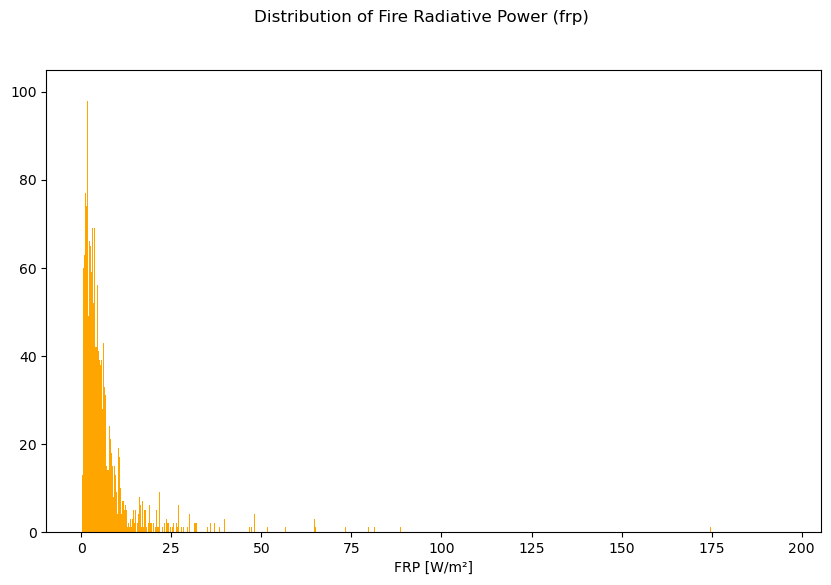

In [6]:
## make histogram of "frp" column -> how is the data distributed?

fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    gdf_fire["frp"].dropna(),
    bins=3000,
    color = "orange"
)
fig.suptitle("Distribution of Fire Radiative Power (frp)", fontsize = 12)
ax.set_xlabel("FRP [W/m²]")

In [7]:
# filter for max and min value of frp, add float to only get the number
max_value = float(gdf_fire["frp"].max())
min_value = float(gdf_fire["frp"].min())

print(f"The maximum value of FRP is {max_value} W/m² and the minimum value of FRP is {min_value} W/m².")
print(f"The distribution of the values is heavily right-skewed. ")

The maximum value of FRP is 195.68 W/m² and the minimum value of FRP is 0.08 W/m².
The distribution of the values is heavily right-skewed. 


In [8]:
# get mean and median values for frp
mean_value = float(gdf_fire["frp"].mean())
median_value = float(gdf_fire["frp"].median())

print(f"The mean value of FRP is {mean_value:.3f} W/m² and the median value of FRP is {median_value} W/m².")

The mean value of FRP is 6.302 W/m² and the median value of FRP is 3.93 W/m².


#### **Convert Brightness Values from Kelvin to Degrees Celsius °C**

0 Kelvin = -273.15 °C

Conversion: °C = °K - 273.15

apply this on column bright_ti4

In [9]:
gdf_fire["bright_ti4_celsius"] = gdf_fire["bright_ti4"] - 273.15

gdf_fire.head(7)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry,bright_ti4_celsius
0,-22.08567,-39.82763,302.72,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,287.93,3.28,N,POINT (-39.82763 -22.08567),29.57
1,-22.08418,-39.83372,340.87,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,288.12,5.12,N,POINT (-39.83372 -22.08418),67.72
2,-22.08301,-39.82693,305.60,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,288.00,3.91,N,POINT (-39.82693 -22.08301),32.45
3,-22.08148,-39.83301,333.26,0.63,0.72,2026-05-15,258,N20,VIIRS,n,2.0NRT,288.26,3.91,N,POINT (-39.83301 -22.08148),60.11
4,-20.25002,-40.24485,299.34,0.73,0.76,2026-05-15,258,N20,VIIRS,n,2.0NRT,277.17,1.67,N,POINT (-40.24485 -20.25002),26.19
5,-20.24686,-40.23722,299.54,0.73,0.76,2026-05-15,258,N20,VIIRS,n,2.0NRT,278.41,3.69,N,POINT (-40.23722 -20.24686),26.39
6,-20.24514,-40.24422,310.75,0.73,0.76,2026-05-15,258,N20,VIIRS,n,2.0NRT,277.67,3.36,N,POINT (-40.24422 -20.24514),37.60


#### **Filter Data for Confindence Values without low confidence** 
The confidence attribute identifies the quality of every hotspot/fire pixel. It accounts for sun glint contamination during the day. Areas with low confidence (l) are associated with areas of sun glint. Nominal confidence pixels (n) are free of potential sun glint contamination. Pixels showing high confidence (h) are indicative for saturated day or nighttime pixels.

l: low

n: nominal

h: high


In [10]:
gdf_fire_reduced = gdf_fire[(gdf_fire["confidence"]!="l")].copy()
gdf_fire_reduced.head(10)

# check if no low confidence fires are included

gdf_fire_reduced["confidence"].unique()

#other method
#gdf_fire_reduced[gdf_fire_reduced["confidence"] == "l"]

<ArrowStringArray>
['n', 'h']
Length: 2, dtype: str

#### **Create Map**

In [ ]:
## This map zooms in on the Northern Part of South America, as there are several clusters of fires
# plus here a quartile distribution of the brightness values is included -> thematic map
# plus zoom control is added, so it is not possible to zoom out further than South America


import numpy as np
import branca.colormap as cm




# initialize basemap centerd on South America, add a zoom control limit
min_lon, max_lon = -81.5, -35.0
min_lat, max_lat = -65.0, 14.5


map2 = folium.Map(
    max_bounds = True,
    location = [8, -69],  #7 = latitute, 7 degrees north of equator, -65 = longitude, 65 degrees west of the prime meridian
    zoom_start = 6, 
    tiles = "CartoDB DarkMatter",
    control_scale = True,
    min_lat = min_lat,
    max_lat = max_lat,
    min_lon = min_lon,
    max_lon = max_lon
                         
)

# add cluster (maybe take this out later)
marker_cluster = MarkerCluster(name="Scaled Fire Detections Cluster").add_to(map2)

# define colormap for marker

#colormap = cm.linear.YlOrRd_09.scale(
 #   gdf_fire_reduced["bright_ti4_celsius"].min(),
  #  gdf_fire_reduced["bright_ti4_celsius"].max()
#)

# make quartiles for brightness so it is a thematic map (?? check with GEO123)
brightness_quartiles = statistics.quantiles(gdf_fire_reduced["bright_ti4_celsius"], n=4)

q1, q2, q3 = brightness_quartiles # quartiles give threshold values, so the first is <=x, the second is x-y, the third y-z, and the las >=Z
                                  # q1, q2, q3 indicate the "Trennlinie"



# assign colours to quartiles
quartile_colors = {
    1: "#f9f99a",
    2: "#fbc03f",
    3: "#f77619",
    4: "#ac0204"
}

# 1-4 are the keys of the quartile_colours dictionary, the hexcodes are the values
# in the for loop, I access the key of the dictionary to get the value of it


for idx, row in gdf_fire_reduced.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    brightness = int(row["bright_ti4_celsius"])

    # assign color based on brightness quartiles
    if brightness <= q1:
        color = quartile_colors[1]

    elif brightness <= q2:
        color = quartile_colors[2]

    elif brightness <= q3:
        color = quartile_colors[3]

    else: color = quartile_colors[4]


    tooltip_text = f"Brightness: {brightness} °C"

    # mathematical scaling of the marker size based on the "frp_sqrt" column
    # base size of 14px plus an increase based on the square root of frp (as done in Lesson8)
    icon_size = 25 + (np.sqrt(row["frp"])*3)

    # define color of circle border; fire detected at night = blue, fire detected during day = white
    if row["daynight"] == "N":
        border_color = "blue" 

    else: border_color = "white"

    # add a custom CSS to draw a circle
    icon_html = f"""
    <div style="
    color: {color}; 
    background: {color};
    border-radius: 50%;
    width: {icon_size}px;
    height: {icon_size}px;
    display: flex;
    align-items: center;
    justify-content: center;
    border: 2px solid {border_color};
    opacity: 0.8;
    ">
    <i class="fa fa-fire" style = "color: {color};"></i>
    </div>
    """


    # apply the custom HTML using DivIcon
    folium.Marker(
        location = [lat, lon],
        icon = folium.DivIcon(
            html = icon_html,
            icon_size = (icon_size, icon_size),
            icon_anchor = (icon_size/2, icon_size/2),   
        ),
        tooltip = tooltip_text,
    ).add_to(marker_cluster)


legend_html = """
<div style = "position: fixed;
bottom: 50px; 
left: 50px;
width: 200px; 
height: 350px;
background-color: lightgrey;
z-index:9999;
font-size:11px;
padding: 10px;
border: 2px solid darkgrey;
">

<b>Cluster</b><br>
<i style="background:#6ecc39;width:20px;height:10px;float:left;margin-right:8px;"></i> Small Cluster: 1-9 Fires<br>

<i style="background:#f0c20c;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium Cluster: 10-99 Fires<br>

<i style="background:#f18017;width:20px;height:10px;float:left;margin-right:8px;"></i> Big Cluster:  100+ Fires
<hr style="margin:6px 0;">
<b>Fire Brightness (°C)</b><br>

<i style="background:#ffffcc;width:20px;height:10px;float:left;margin-right:8px;"></i> Low: <= 46.16<br>

<i style="background:#feb24c;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium: 46.16 - 59.90<br>

<i style="background:#f03b20;width:20px;height:10px;float:left;margin-right:8px;"></i> High: 59.90 - 67.87<br>

<i style="background:#bd0026;width:20px;height:10px;float:left;margin-right:8px;"></i> Extreme: >= 67.87
<hr style="margin:6px 0;">
<b>Detection Time</b><br>

<span style="   
display: inline-block;
width: 12px;
height: 12px;
border: 3px solid white;
border-radius: 50%;
background-color: transparent;
margin-right: 8px;
"></span>
Day<br><br>

<span style="
display: inline-block;
width: 12px;
height: 12px;
border: 3px solid blue;
border-radius: 50%;
background-color: transparent;
margin-right: 8px;
"></span>
Night
<hr style="margin:6px 0;">
<b>Fire Intensity </b><br>


</div>
"""

map2.get_root().html.add_child(folium.Element(legend_html))

# add interactive layer control
folium.LayerControl().add_to(map2)

# save map because I cannot display it in VS Code
map2.save("fire_map2_scaled_markers.html")

map2







    